<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Histogram**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-01-12 14:23:01--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-data.sqlite’

survey-data.sqlite  100%[===================>] 201.62M  62.1MB/s    in 3.3s    

2026-01-12 14:23:04 (62.0 MB/s) - ‘survey-data.sqlite’ saved [211415040/211415040]



#### Install the required libraries and import them


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 151.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 159.6 MB/s eta 0:00:00


In [3]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 163.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 125.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 140.8 MB/s eta 0:00:00


In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [5]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [6]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


**Demo 2: List all tables**


In [7]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


**Demo 3: Group data by age**


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


In [12]:
!pip install seaborn




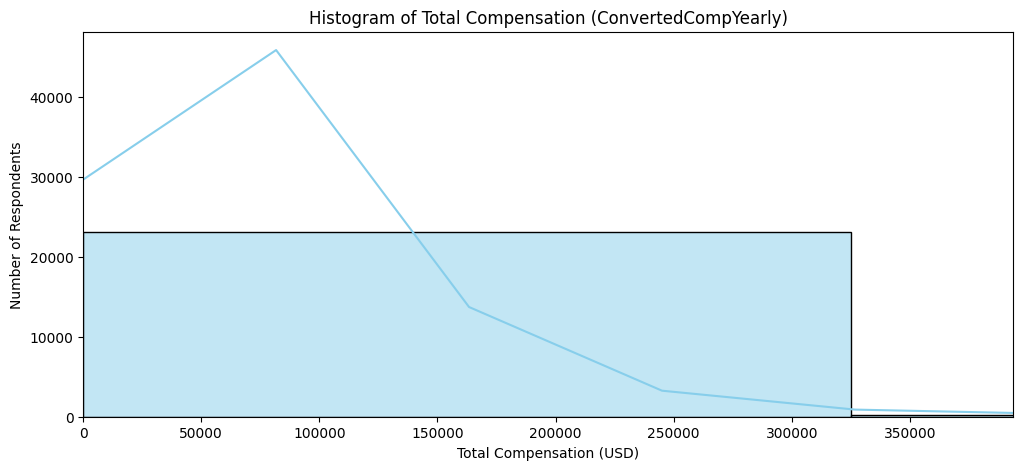

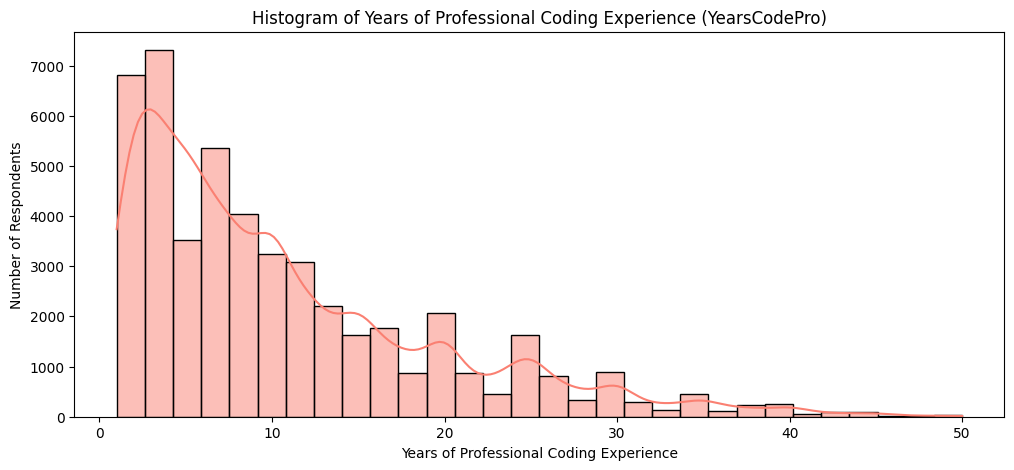

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the survey data
data_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(data_url)

# Ensure numeric columns and drop missing values
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

comp_df = df['ConvertedCompYearly'].dropna()
years_df = df['YearsCodePro'].dropna()

# Plot histogram for Total Compensation
plt.figure(figsize=(12,5))
sns.histplot(comp_df, bins=50, kde=True, color='skyblue')
plt.title("Histogram of Total Compensation (ConvertedCompYearly)")
plt.xlabel("Total Compensation (USD)")
plt.ylabel("Number of Respondents")
plt.xlim(0, comp_df.quantile(0.99))  # focus on 99th percentile to reduce outlier effect
plt.show()

# Plot histogram for Years of Professional Coding Experience
plt.figure(figsize=(12,5))
sns.histplot(years_df, bins=30, kde=True, color='salmon')
plt.title("Histogram of Years of Professional Coding Experience (YearsCodePro)")
plt.xlabel("Years of Professional Coding Experience")
plt.ylabel("Number of Respondents")
plt.show()


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


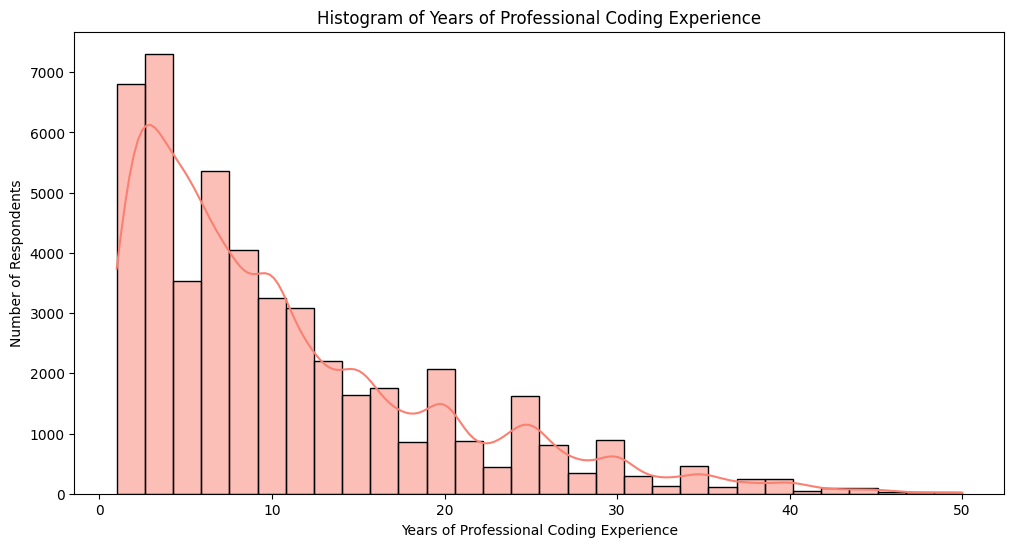

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the survey data
data_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(data_url)

# Convert YearsCodePro to numeric, coerce errors, and drop missing values
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')
years_df = df['YearsCodePro'].dropna()

# Plot histogram
plt.figure(figsize=(12,6))
sns.histplot(years_df, bins=30, kde=True, color='salmon')
plt.title("Histogram of Years of Professional Coding Experience")
plt.xlabel("Years of Professional Coding Experience")
plt.ylabel("Number of Respondents")
plt.show()


### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


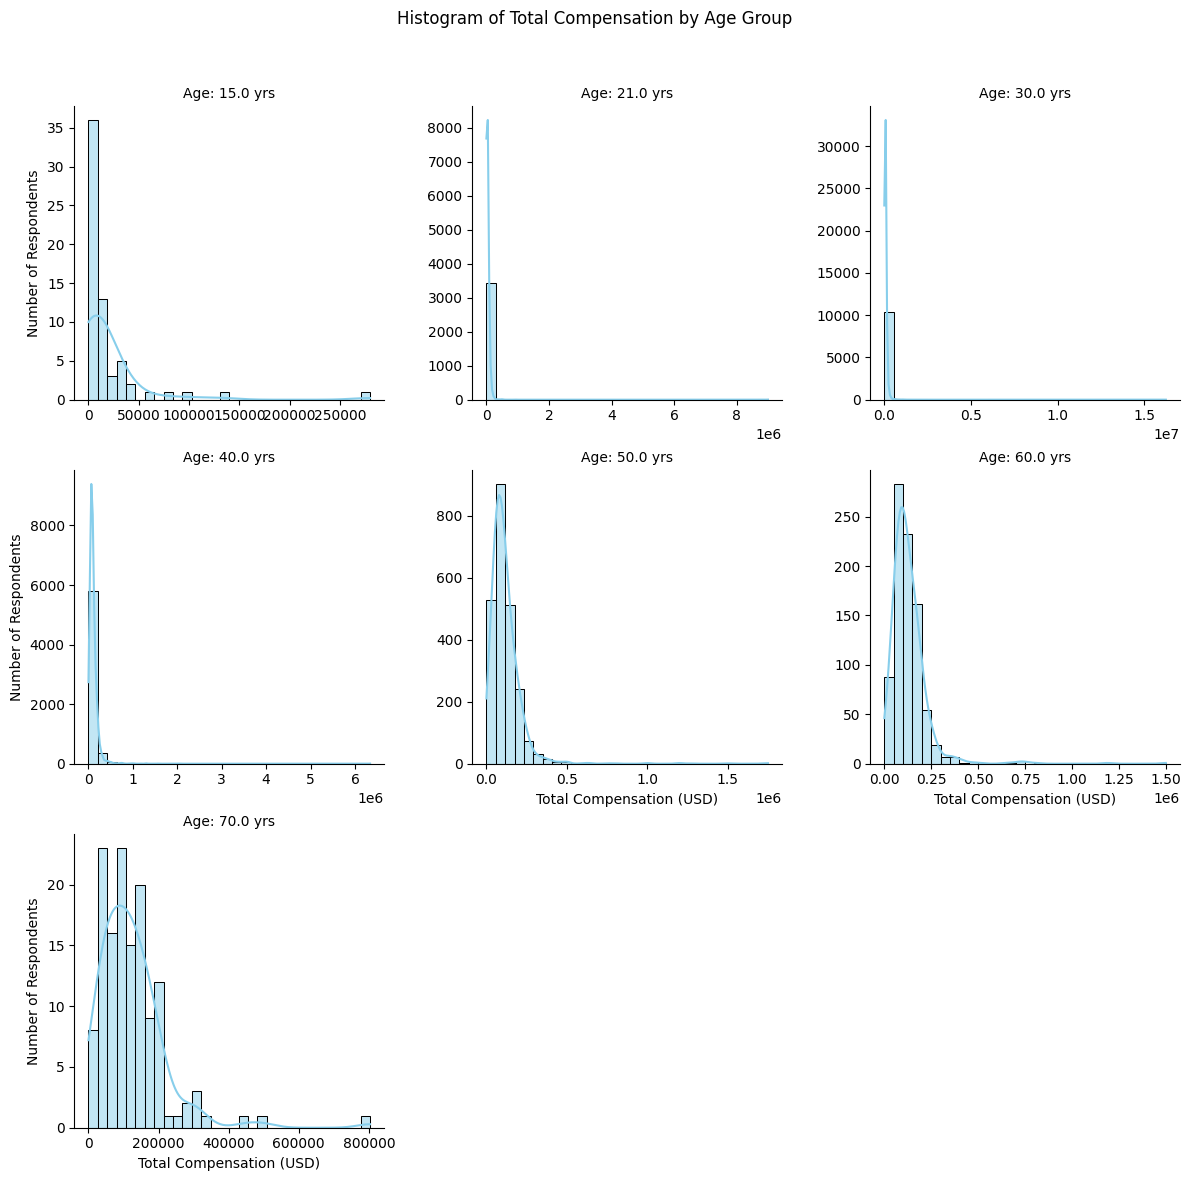

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the survey data
data_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(data_url)

# Convert ConvertedCompYearly to numeric and drop missing values
df['ConvertedCompYearly'] = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')

# Map Age categories to numeric midpoints for grouping
age_mapping = {
    'Under 18 years old': 15,
    '18-24 years old': 21,
    '25-34 years old': 30,
    '35-44 years old': 40,
    '45-54 years old': 50,
    '55-64 years old': 60,
    '65 years or older': 70
}

df['Age_numeric'] = df['Age'].map(age_mapping)

# Keep only rows with valid compensation and age
df_filtered = df.dropna(subset=['ConvertedCompYearly', 'Age_numeric'])

# Plot histograms by Age group using FacetGrid
g = sns.FacetGrid(df_filtered, col='Age_numeric', col_wrap=3, height=4, sharex=False, sharey=False)
g.map_dataframe(sns.histplot, 'ConvertedCompYearly', bins=30, color='skyblue', kde=True)
g.set_axis_labels("Total Compensation (USD)", "Number of Respondents")
g.set_titles("Age: {col_name} yrs")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Histogram of Total Compensation by Age Group")
plt.show()


**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


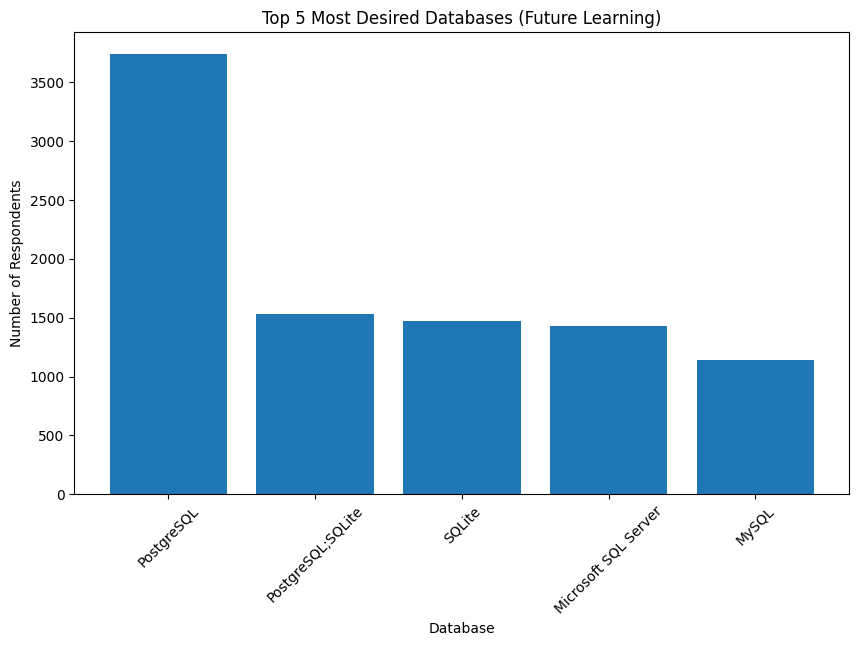

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(url)

# Drop missing values
db_series = df['DatabaseWantToWorkWith'].dropna()

# Get top 5 desired databases
top5 = db_series.value_counts().head(5)

# Plot only if data exists
if not top5.empty:
    plt.figure(figsize=(10,6))
    plt.bar(top5.index, top5.values)
    plt.title("Top 5 Most Desired Databases (Future Learning)")
    plt.xlabel("Database")
    plt.ylabel("Number of Respondents")
    plt.xticks(rotation=45)
    plt.show()
else:
    print("No data available to plot.")


### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


/tmp/ipykernel_302/3523784569.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_databases.index, y=top_databases.values, palette="viridis")


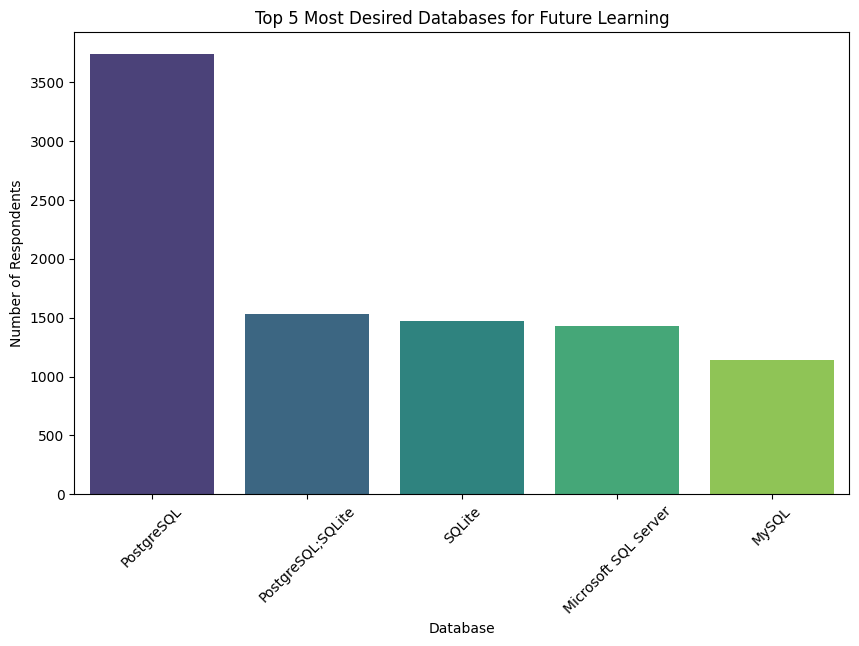

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the survey data
data_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(data_url)

# Drop missing values in DatabaseWantToWorkWith
df_db = df['DatabaseWantToWorkWith'].dropna()

# Get the top 5 most desired databases
top_databases = df_db.value_counts().nlargest(5)

# Plot a bar chart
plt.figure(figsize=(10,6))
sns.barplot(x=top_databases.index, y=top_databases.values, palette="viridis")
plt.title("Top 5 Most Desired Databases for Future Learning")
plt.xlabel("Database")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45)
plt.show()


**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).


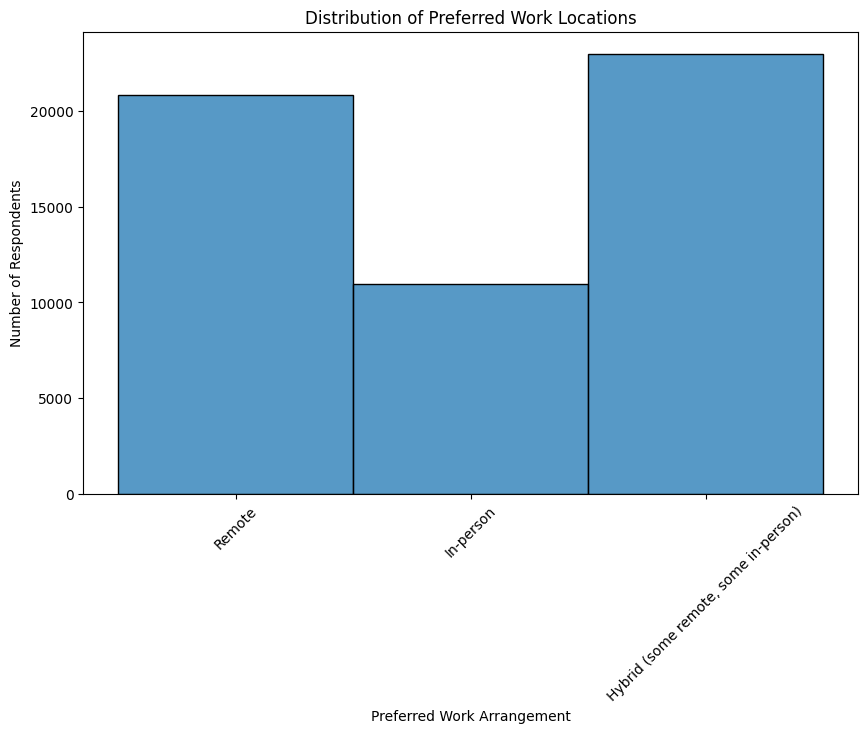

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Drop missing values in RemoteWork column
df_remote = df['RemoteWork'].dropna()

# Plot histogram (count-based)
plt.figure(figsize=(10, 6))
sns.histplot(df_remote, discrete=True)

plt.title("Distribution of Preferred Work Locations")
plt.xlabel("Preferred Work Arrangement")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45)
plt.show()


### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


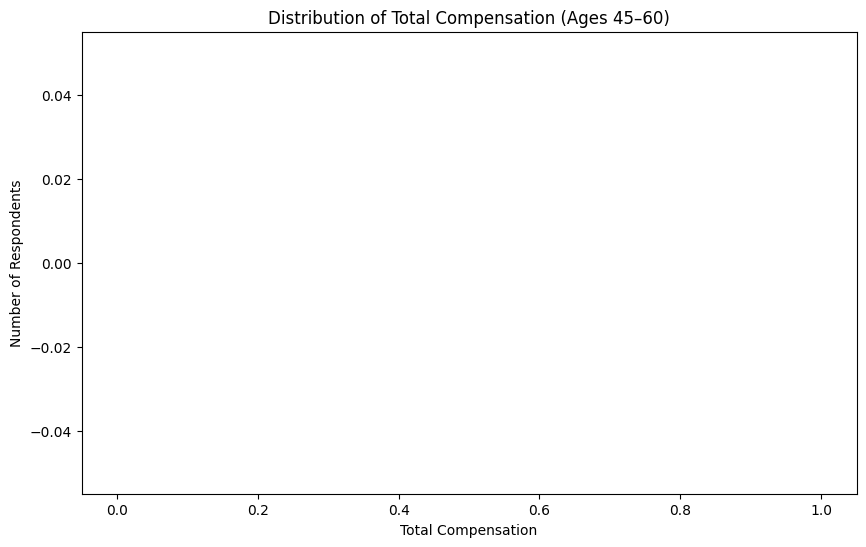

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert Age to numeric (invalid values become NaN)
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

# Filter respondents aged 45 to 60
df_mid_career = df[(df['Age'] >= 45) & (df['Age'] <= 60)]

# Convert CompTotal to numeric as well (important!)
df_mid_career['CompTotal'] = pd.to_numeric(
    df_mid_career['CompTotal'], errors='coerce'
)

# Drop missing or zero compensation values
comp_data = df_mid_career['CompTotal'].dropna()
comp_data = comp_data[comp_data > 0]

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(comp_data, bins=30)

plt.title("Distribution of Total Compensation (Ages 45–60)")
plt.xlabel("Total Compensation")
plt.ylabel("Number of Respondents")
plt.show()



**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert YearsCodePro to numeric (handle text like 'Less than 1 year', 'More than 50 years')
df['YearsCodePro'] = pd.to_numeric(df['YearsCodePro'], errors='coerce')

# Drop missing JobSat and YearsCodePro
df_job = df[['JobSat', 'YearsCodePro']].dropna()


/tmp/ipykernel_302/525329232.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['ExperienceGroup', 'JobSat'])


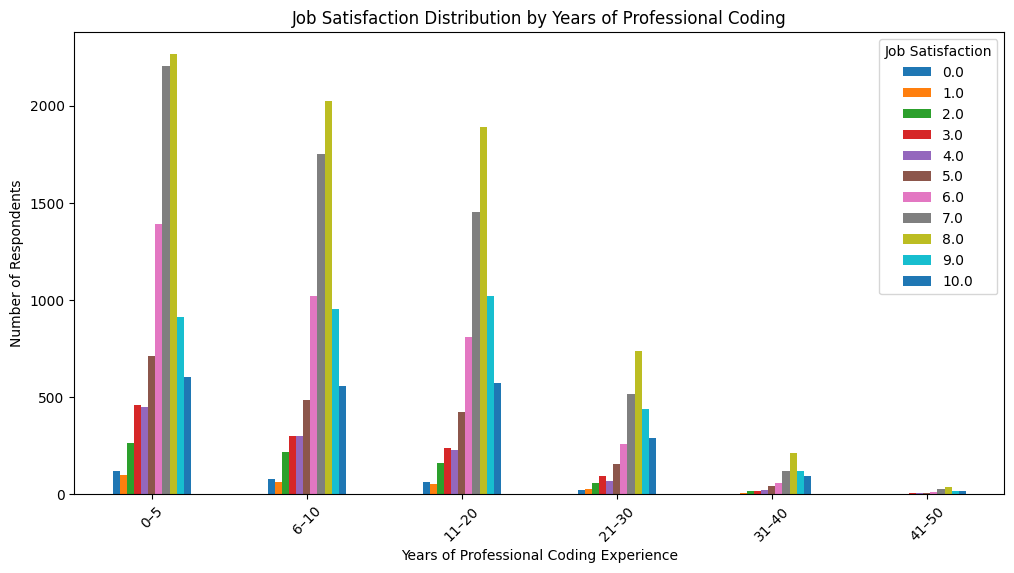

In [22]:
# Create experience bins
bins = [0, 5, 10, 20, 30, 40, 50]
labels = ['0–5', '6–10', '11–20', '21–30', '31–40', '41–50']

df_job['ExperienceGroup'] = pd.cut(
    df_job['YearsCodePro'], bins=bins, labels=labels, right=True
)

# Count JobSat values per experience group
job_sat_counts = (
    df_job
    .groupby(['ExperienceGroup', 'JobSat'])
    .size()
    .unstack(fill_value=0)
)

# Plot histogram-style bar chart
job_sat_counts.plot(kind='bar', figsize=(12, 6))

plt.title("Job Satisfaction Distribution by Years of Professional Coding")
plt.xlabel("Years of Professional Coding Experience")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45)
plt.legend(title="Job Satisfaction")
plt.show()


### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [ ]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
